In [1]:
# ============================================================
# 1. IMPORTS AND CONFIGURATION
# ============================================================

#import warnings
#warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    brier_score_loss
)

import kagglehub

# Reproducibility
RANDOM_STATE = 42

# Significance level
ALPHA = 0.05

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

sns.set_theme(style="whitegrid")

print("Setup completed successfully.")

Setup completed successfully.


In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

# Download the IBM HR Analytics Employee Attrition dataset
dataset_path = kagglehub.dataset_download(
    "pavansubhasht/ibm-hr-analytics-attrition-dataset"
)

print("Dataset path:")
print(dataset_path)

# Load the CSV
file_path = dataset_path + "/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(file_path)

print("\nDataset loaded successfully.")
print(f"Number of observations: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Dataset path:
/kaggle/input/ibm-hr-analytics-attrition-dataset

Dataset loaded successfully.
Number of observations: 1470
Number of variables: 35


In [3]:
# ============================================================
# 3. INITIAL DATA INSPECTION
# ============================================================

print("Dataset shape:")
print(df.shape)

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nFirst five rows:")
display(df.head())

print("\nAttrition distribution:")
display(df["Attrition"].value_counts())

print("\nAttrition proportions:")
display(
    df["Attrition"]
    .value_counts(normalize=True)
    .rename("proportion")
    .to_frame()
)

Dataset shape:
(1470, 35)

Data types:


,dtype
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64



First five rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2



Attrition distribution:


,count
Attrition,
No,1233
Yes,237



Attrition proportions:


,proportion
Attrition,
No,0.8388
Yes,0.1612


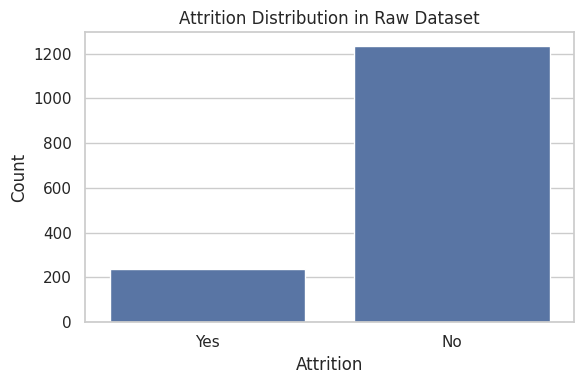

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# ATTRITION DISTRIBUTION (RAW DATA)
# ============================================================

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition')
plt.title('Attrition Distribution in Raw Dataset')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# 4. DATA QUALITY CHECKS
# ============================================================

# Missing values
missing_values = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

print("Missing values:")
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found.")

# Duplicate rows
duplicate_count = df.duplicated().sum()

print(f"\nNumber of duplicated rows: {duplicate_count}")

# Constant columns
constant_columns = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 1
]

print("\nConstant columns:")
print(constant_columns)

Missing values:


,0


No missing values found.

Number of duplicated rows: 0

Constant columns:
['EmployeeCount', 'Over18', 'StandardHours']


In [6]:
# ============================================================
# 5. DATA CLEANING
# ============================================================

df_clean = df.copy()

# Columns that contain no useful variation / are identifiers
columns_to_remove = [
    "EmployeeCount",
    "Over18",
    "StandardHours",
    "EmployeeNumber"
]

df_clean = df_clean.drop(columns=columns_to_remove)

print("Removed columns:")
print(columns_to_remove)

print("\nNew dataset shape:")
print(df_clean.shape)

Removed columns:
['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']

New dataset shape:
(1470, 31)


In [7]:
# ============================================================
# 6. VERIFY CLEANED DATA
# ============================================================

print("Remaining columns:")
print(df_clean.columns.tolist())

print("\nMissing values after cleaning:")
display(
    df_clean.isna().sum().sort_values(ascending=False).head(10)
)

print("\nDuplicate rows after cleaning:")
print(df_clean.duplicated().sum())

Remaining columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Missing values after cleaning:


,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0



Duplicate rows after cleaning:
0


In [8]:
# ============================================================
# 7. DEFINE TARGET VARIABLE
# ============================================================

TARGET = "Attrition"

# Binary representation:
# 1 = employee left
# 0 = employee stayed

df_clean["AttritionBinary"] = (
    df_clean[TARGET] == "Yes"
).astype(int)

print("Target distribution:")
display(
    df_clean[TARGET]
    .value_counts()
    .rename("count")
    .to_frame()
)

print("\nBinary target distribution:")
display(
    df_clean["AttritionBinary"]
    .value_counts()
    .rename("count")
    .to_frame()
)

Target distribution:


,count
Attrition,
No,1233
Yes,237



Binary target distribution:


,count
AttritionBinary,
0,1233
1,237


In [9]:
# ============================================================
# 8. DEFINE VARIABLE TYPES
# ============================================================

# Continuous / quantitative variables
continuous_vars = [
    "Age",
    "DailyRate",
    "HourlyRate",
    "MonthlyIncome",
    "MonthlyRate",
    "DistanceFromHome",
    "PercentSalaryHike",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "NumCompaniesWorked",
    "TrainingTimesLastYear"
]

# Ordinal variables
ordinal_vars = [
    "Education",
    "JobLevel",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance",
    "JobInvolvement",
    "PerformanceRating",
    "StockOptionLevel"
]

# Nominal categorical variables
categorical_vars = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "OverTime"
]

# Check that all variables exist
all_analysis_vars = (
    continuous_vars +
    ordinal_vars +
    categorical_vars
)

missing_analysis_vars = [
    col for col in all_analysis_vars
    if col not in df_clean.columns
]

print("Missing variables from classification:")
print(missing_analysis_vars)

print("\nNumber of continuous variables:", len(continuous_vars))
print("Number of ordinal variables:", len(ordinal_vars))
print("Number of categorical variables:", len(categorical_vars))

Missing variables from classification:
[]

Number of continuous variables: 14
Number of ordinal variables: 9
Number of categorical variables: 7


In [10]:
# ============================================================
# 9. VERIFY VARIABLE VALUES
# ============================================================

print("Categorical variables and their levels:\n")

for col in categorical_vars:
    print(f"{col}:")
    print(df_clean[col].unique())
    print()

print("Ordinal variables and their levels:\n")

for col in ordinal_vars:
    print(f"{col}:")
    print(sorted(df_clean[col].dropna().unique()))
    print()

Categorical variables and their levels:

BusinessTravel:
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Department:
['Sales' 'Research & Development' 'Human Resources']

EducationField:
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

Gender:
['Female' 'Male']

JobRole:
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

MaritalStatus:
['Single' 'Married' 'Divorced']

OverTime:
['Yes' 'No']

Ordinal variables and their levels:

Education:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

JobLevel:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

JobSatisfaction:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

EnvironmentSatisfaction:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

RelationshipSatisfaction:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]



In [11]:
# ============================================================
# 10. DESCRIPTIVE STATISTICS
# ============================================================

print("Descriptive statistics for continuous variables:")

display(
    df_clean[continuous_vars]
    .describe()
    .T
)

Descriptive statistics for continuous variables:


,count,mean,std,min,25%,50%,75%,max
Age,1470.0000,36.9238,9.1354,18.0000,30.0000,36.0000,43.0000,60.0000
DailyRate,1470.0000,802.4857,403.5091,102.0000,465.0000,802.0000,1157.0000,1499.0000
HourlyRate,1470.0000,65.8912,20.3294,30.0000,48.0000,66.0000,83.7500,100.0000
MonthlyIncome,1470.0000,6502.9313,4707.9568,1009.0000,2911.0000,4919.0000,8379.0000,19999.0000
MonthlyRate,1470.0000,14313.1034,7117.7860,2094.0000,8047.0000,14235.5000,20461.5000,26999.0000
DistanceFromHome,1470.0000,9.1925,8.1069,1.0000,2.0000,7.0000,14.0000,29.0000
PercentSalaryHike,1470.0000,15.2095,3.6599,11.0000,12.0000,14.0000,18.0000,25.0000
TotalWorkingYears,1470.0000,11.2796,7.7808,0.0000,6.0000,10.0000,15.0000,40.0000
YearsAtCompany,1470.0000,7.0082,6.1265,0.0000,3.0000,5.0000,9.0000,40.0000
YearsInCurrentRole,1470.0000,4.2293,3.6231,0.0000,2.0000,3.0000,7.0000,18.0000


In [12]:
# ============================================================
# 11. DESCRIPTIVE STATISTICS BY ATTRITION
# ============================================================

continuous_by_attrition = (
    df_clean
    .groupby(TARGET)[continuous_vars]
    .agg(["count", "mean", "median", "std"])
    .T
)

display(continuous_by_attrition)

Attrition                              No        Yes
Age                     count   1233.0000   237.0000
                        mean      37.5612    33.6076
                        median    36.0000    32.0000
                        std        8.8884     9.6893
DailyRate               count   1233.0000   237.0000
                        mean     812.5045   750.3629
                        median   817.0000   699.0000
                        std      403.2084   401.8995
HourlyRate              count   1233.0000   237.0000
                        mean      65.9521    65.5738
                        median    66.0000    66.0000
                        std       20.3808    20.1000
MonthlyIncome           count   1233.0000   237.0000
                        mean    6832.7397  4787.0928
                        median  5204.0000  3202.0000
                        std     4818.2080  3640.2104
MonthlyRate             count   1233.0000   237.0000
                        mean   14265.7794 14559.3080
                        median 14120.0000 14618.0000
                        std     7102.2607  7208.1533
DistanceFromHome        count   1233.0000   237.0000
                        mean       8.9157    10.6329
                        median     7.0000     9.0000
                        std        8.0126     8.4525
PercentSalaryHike       count   1233.0000   237.0000
                        mean      15.2311    15.0970
                        median    14.0000    14.0000
                        std        3.6395     3.7703
TotalWorkingYears       count   1233.0000   237.0000
                        mean      11.8629     8.2447
                        median    10.0000     7.0000
                        std        7.7607     7.1692
YearsAtCompany          count   1233.0000   237.0000
                        mean       7.3690     5.1308
                        median     6.0000     3.0000
                        std        6.0963     5.9500
YearsInCurrentRole      count   1233.0000   237.0000
                        mean       4.4842     2.9030
                        median     3.0000     2.0000
                        std        3.6494     3.1748
YearsSinceLastPromotion count   1233.0000   237.0000
                        mean       2.2344     1.9451
                        median     1.0000     1.0000
                        std        3.2348     3.1531
YearsWithCurrManager    count   1233.0000   237.0000
                        mean       4.3674     2.8523
                        median     3.0000     2.0000
                        std        3.5941     3.1433
NumCompaniesWorked      count   1233.0000   237.0000
                        mean       2.6456     2.9409
                        median     2.0000     1.0000
                        std        2.4601     2.6785
TrainingTimesLastYear   count   1233.0000   237.0000
                        mean       2.8329     2.6245
                        median     3.0000     2.0000
                        std        1.2936     1.2548

In [13]:
# ============================================================
# 12. ATTRITION RATE BY CATEGORICAL VARIABLES
# ============================================================

for col in categorical_vars:

    table = pd.crosstab(
        df_clean[col],
        df_clean[TARGET],
        normalize="index"
    ) * 100

    print(f"\n{col} - Attrition percentage:")
    display(table.round(2))


BusinessTravel - Attrition percentage:


Attrition,No,Yes
BusinessTravel,,
Non-Travel,92.0000,8.0000
Travel_Frequently,75.0900,24.9100
Travel_Rarely,85.0400,14.9600



Department - Attrition percentage:


Attrition,No,Yes
Department,,
Human Resources,80.9500,19.0500
Research & Development,86.1600,13.8400
Sales,79.3700,20.6300



EducationField - Attrition percentage:


...

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.1300,6.8700
Human Resources,76.9200,23.0800
Laboratory Technician,76.0600,23.9400
Manager,95.1000,4.9000
Manufacturing Director,93.1000,6.9000
Research Director,97.5000,2.5000
Research Scientist,83.9000,16.1000
Sales Executive,82.5200,17.4800
Sales Representative,60.2400,39.7600



MaritalStatus - Attrition percentage:


Attrition,No,Yes
MaritalStatus,,
Divorced,89.9100,10.0900
Married,87.5200,12.4800
Single,74.4700,25.5300



OverTime - Attrition percentage:


Attrition,No,Yes
OverTime,,
No,89.5600,10.4400
Yes,69.4700,30.5300


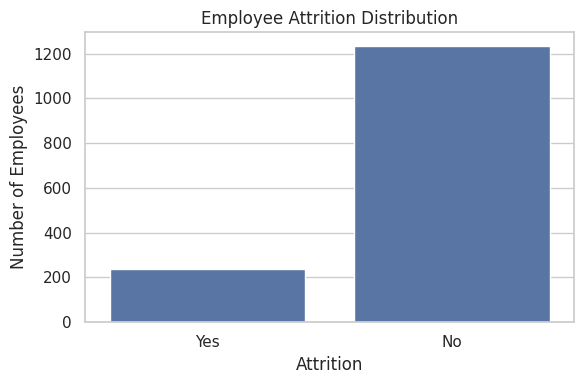

In [14]:
# ============================================================
# 13. TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_clean,
    x=TARGET
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

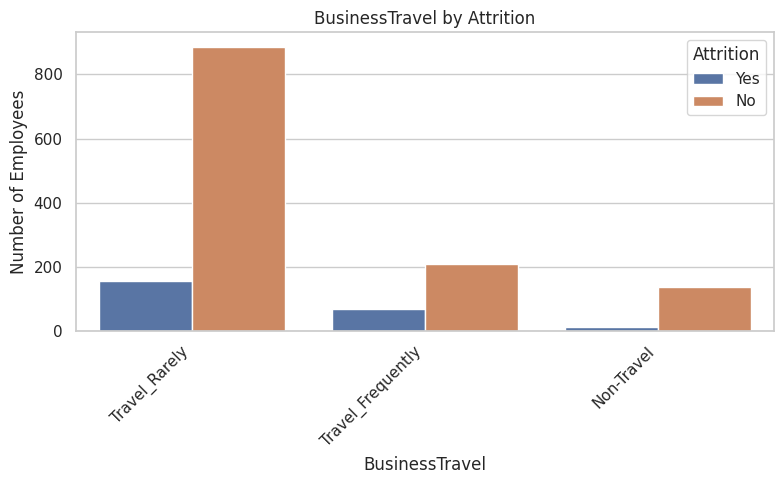

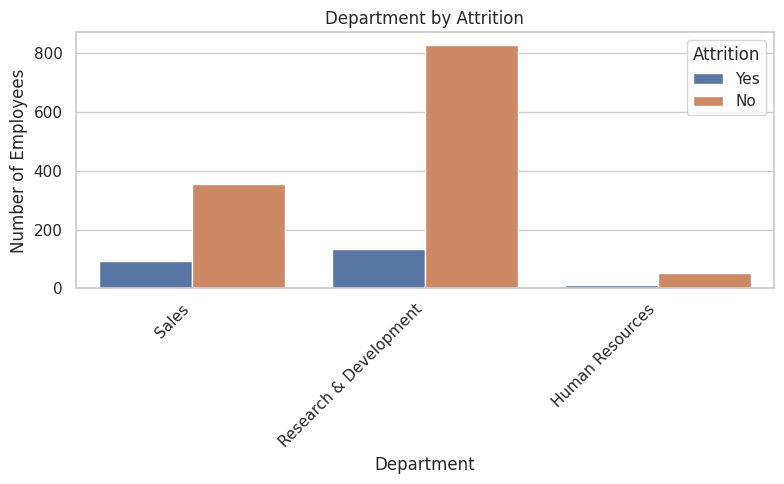

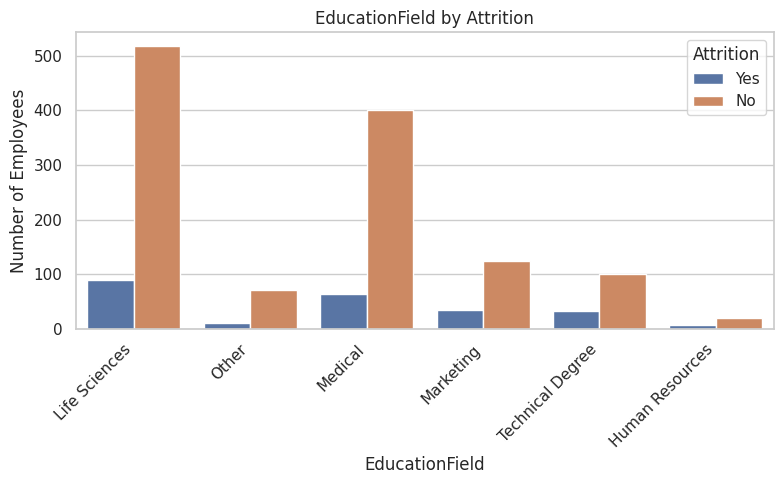

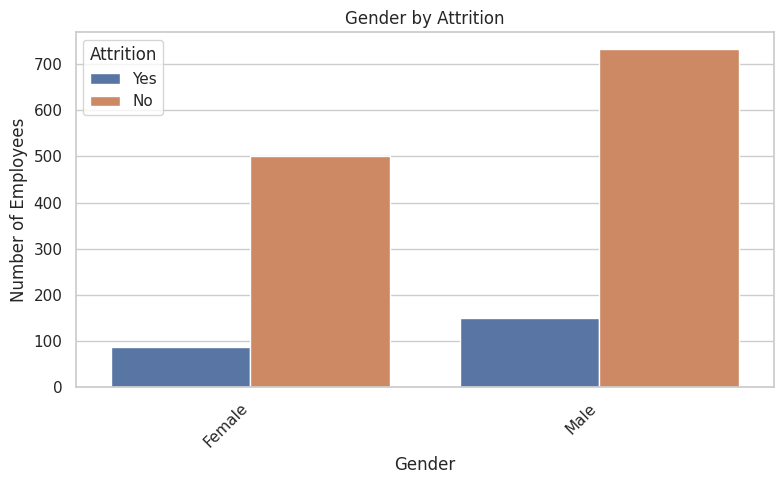

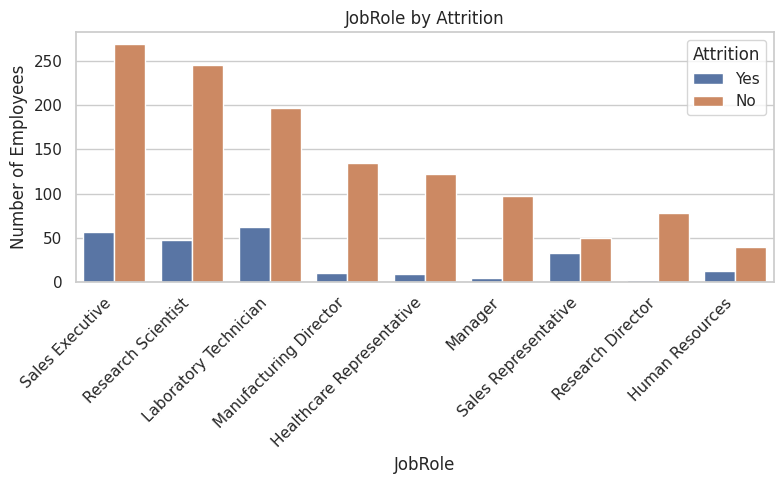

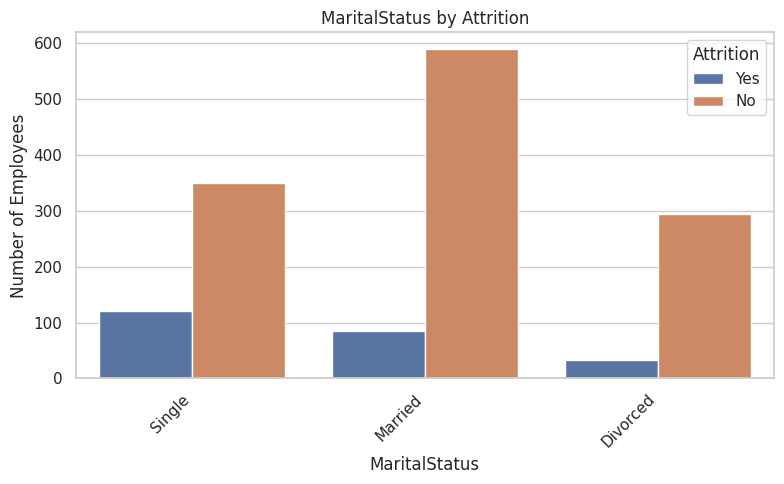

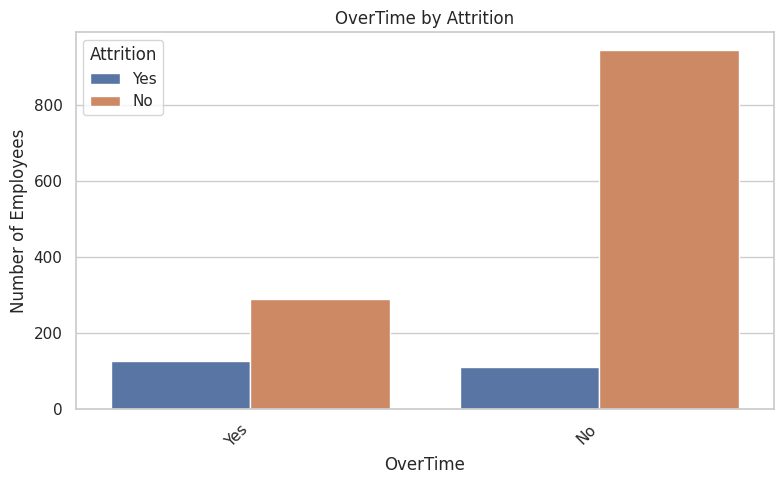

In [15]:
# ============================================================
# 14. CATEGORICAL VARIABLES VS ATTRITION
# ============================================================

for col in categorical_vars:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df_clean,
        x=col,
        hue=TARGET
    )

    plt.title(f"{col} by Attrition")
    plt.xlabel(col)
    plt.ylabel("Number of Employees")

    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

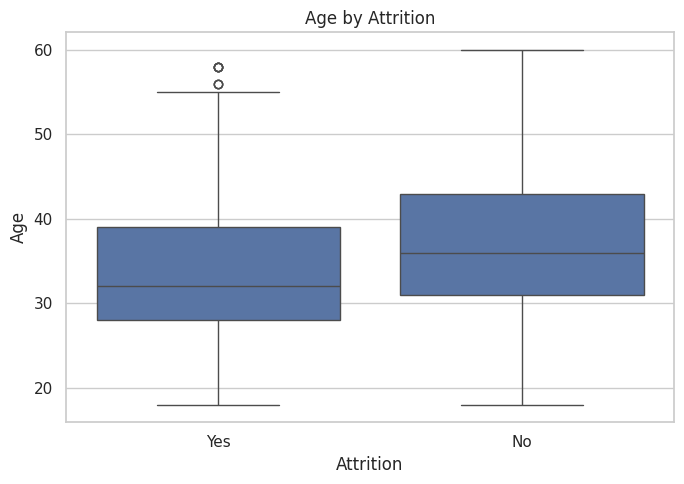

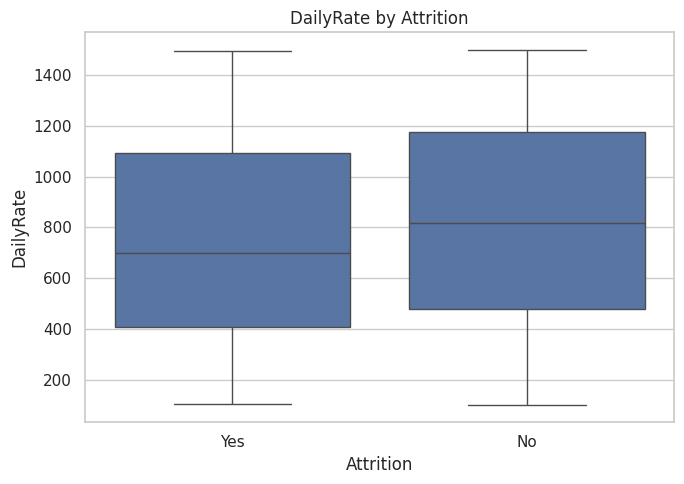

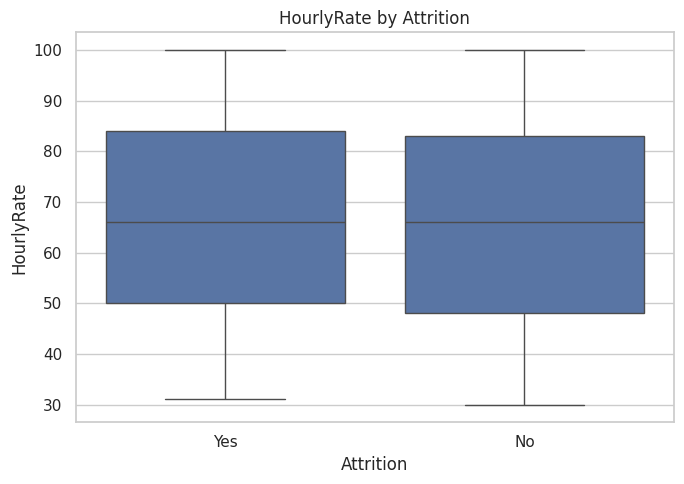

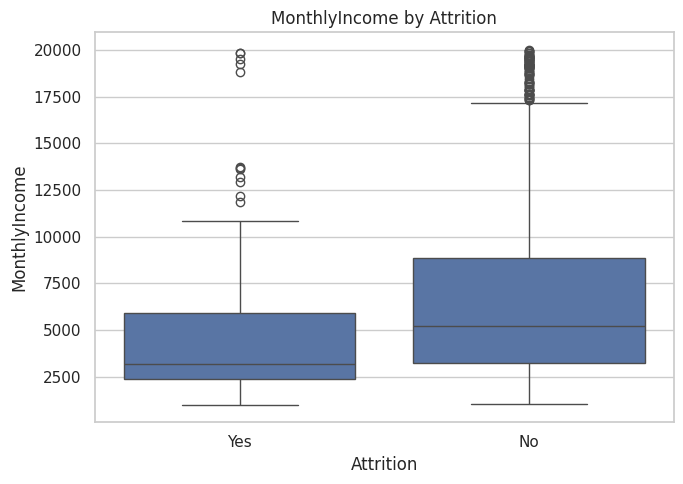

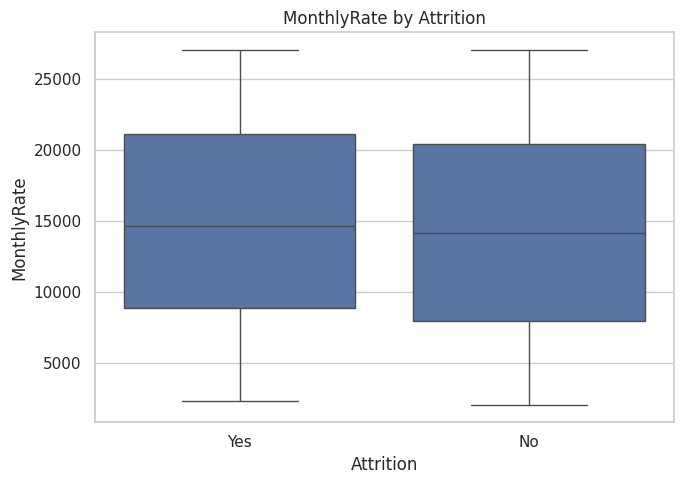

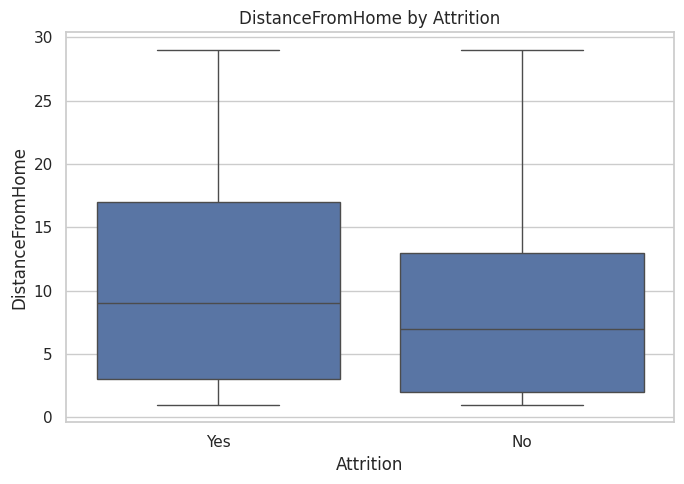

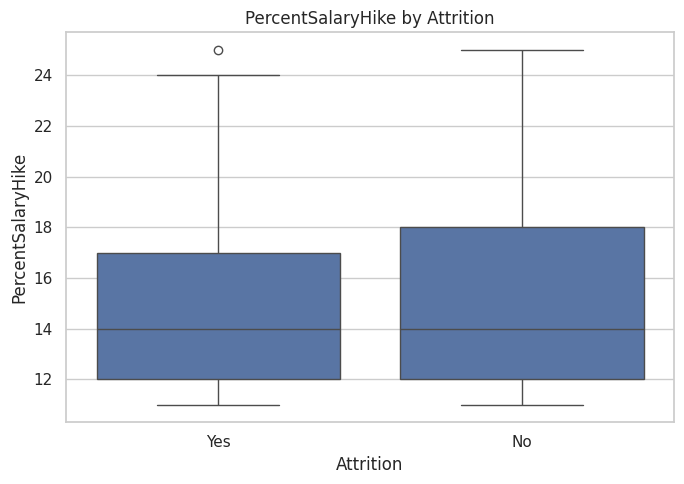

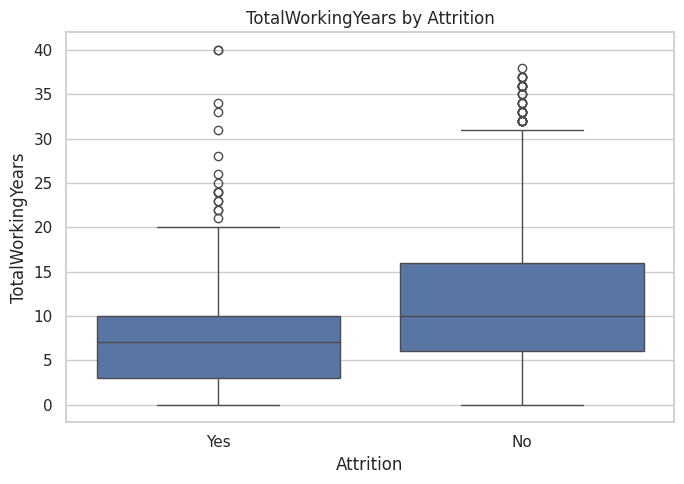

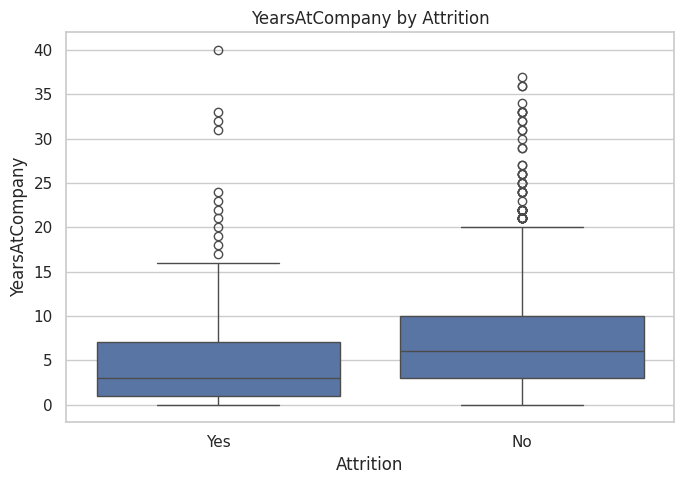

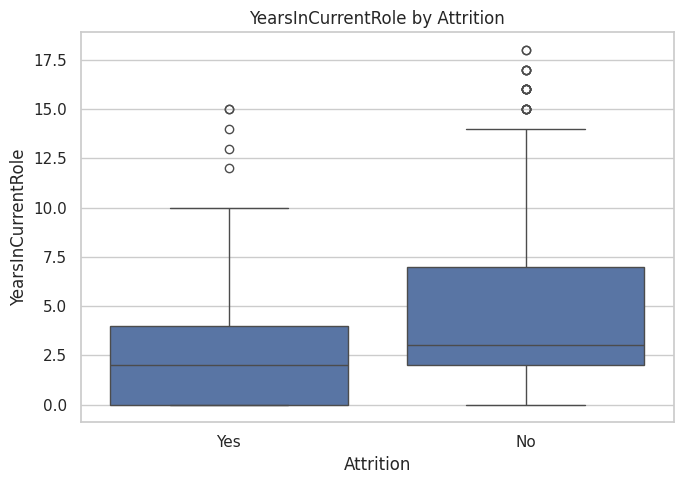

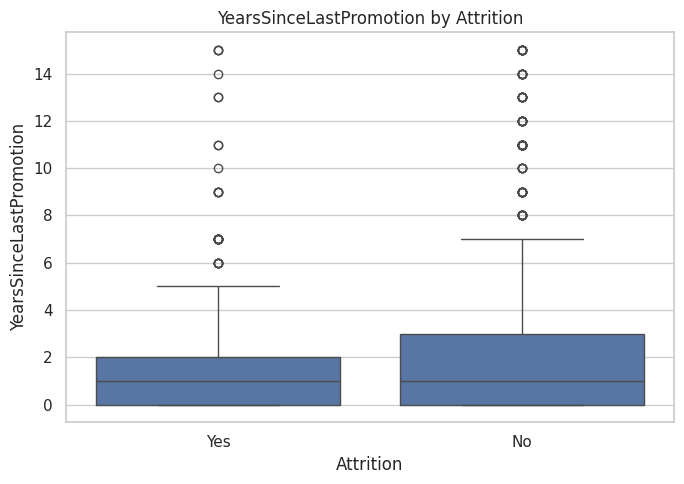

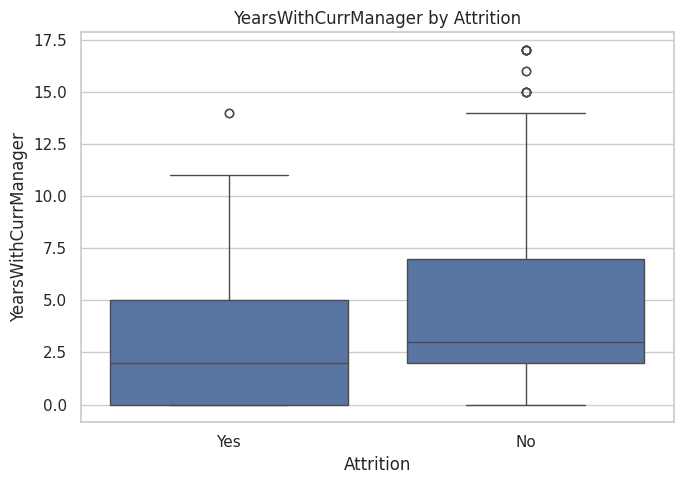

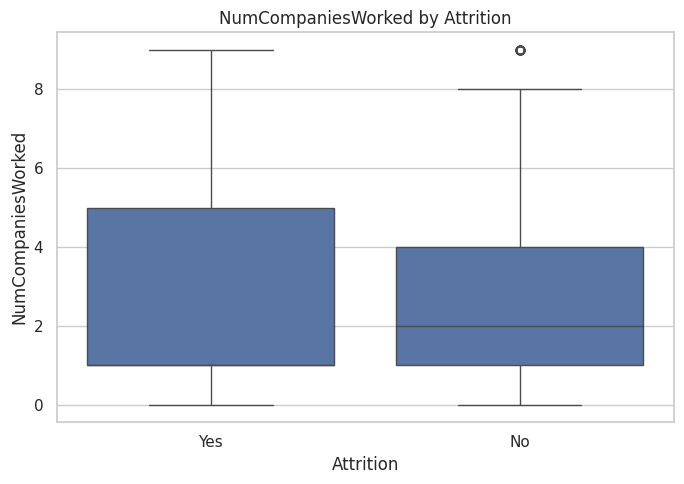

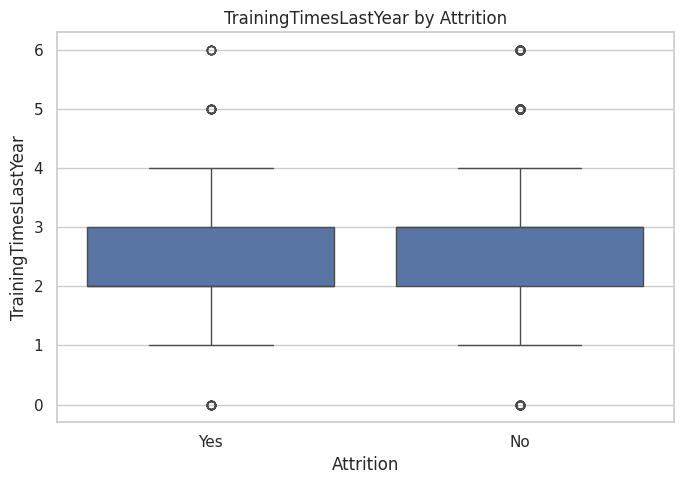

In [16]:
# ============================================================
# 15. CONTINUOUS VARIABLES VS ATTRITION
# ============================================================

for col in continuous_vars:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df_clean,
        x=TARGET,
        y=col
    )

    plt.title(f"{col} by Attrition")
    plt.xlabel("Attrition")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

In [17]:
# ============================================================
# 16. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# Separate predictors and target
X = df_clean.drop(columns=["Attrition", "AttritionBinary"])
y = df_clean["AttritionBinary"]

# First split:
# 70% train
# 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

# Second split:
# Half of temporary = 15% validation
# Half of temporary = 15% test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Dataset sizes:")
print("-----------------------------")
print(f"Full dataset:    {len(df_clean)}")
print(f"Training set:    {len(X_train)}")
print(f"Validation set:  {len(X_val)}")
print(f"Test set:        {len(X_test)}")

Dataset sizes:
-----------------------------
Full dataset:    1470
Training set:    1029
Validation set:  220
Test set:        221


In [18]:
# ============================================================
# 17. VERIFY TARGET DISTRIBUTION AFTER SPLIT
# ============================================================

def print_target_distribution(name, y_data):

    counts = y_data.value_counts().sort_index()
    proportions = y_data.value_counts(normalize=True).sort_index()

    result = pd.DataFrame({
        "count": counts,
        "proportion": proportions
    })

    result.index = ["Stayed (0)", "Left (1)"]

    print(f"\n{name}:")
    display(result)


print_target_distribution("Full dataset", y)
print_target_distribution("Training set", y_train)
print_target_distribution("Validation set", y_val)
print_target_distribution("Test set", y_test)


Full dataset:


,count,proportion
Stayed (0),1233,0.8388
Left (1),237,0.1612



Training set:


,count,proportion
Stayed (0),863,0.8387
Left (1),166,0.1613



Validation set:


,count,proportion
Stayed (0),185,0.8409
Left (1),35,0.1591



Test set:


,count,proportion
Stayed (0),185,0.8371
Left (1),36,0.1629


In [19]:
# ============================================================
# IMPORTANT ANALYSIS RULE
# ============================================================

print("""
DATA SPLIT POLICY
=================

TRAINING SET:
- Exploratory analysis used for model construction
- Variable screening
- Multicollinearity analysis
- Logistic regression fitting
- GLRT/model comparison
- Interaction testing

VALIDATION SET:
- Threshold selection
- Optional model tuning

TEST SET:
- Used ONLY once for final unbiased evaluation
- No variable selection
- No threshold selection
- No model tuning
""")


DATA SPLIT POLICY

TRAINING SET:
- Exploratory analysis used for model construction
- Variable screening
- Multicollinearity analysis
- Logistic regression fitting
- GLRT/model comparison
- Interaction testing

VALIDATION SET:
- Threshold selection
- Optional model tuning

TEST SET:
- Used ONLY once for final unbiased evaluation
- No variable selection
- No threshold selection
- No model tuning



In [20]:
# ============================================================
# 19. MULTICOLLINEARITY ANALYSIS - PREPARATION
# ============================================================

# Variables that we want to investigate for the regression model.
# We intentionally exclude the target.

vif_continuous = [
    "Age",
    "DailyRate",
    "HourlyRate",
    "MonthlyIncome",
    "MonthlyRate",
    "DistanceFromHome",
    "PercentSalaryHike",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "NumCompaniesWorked",
    "TrainingTimesLastYear"
]

vif_ordinal = [
    "Education",
    "JobLevel",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance",
    "JobInvolvement",
    "PerformanceRating",
    "StockOptionLevel"
]

vif_categorical = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "OverTime"
]

vif_variables = (
    vif_continuous +
    vif_ordinal +
    vif_categorical
)

# Keep only variables that actually exist
vif_variables = [
    col for col in vif_variables
    if col in X_train.columns
]

X_vif = X_train[vif_variables].copy()

print("Variables included in VIF analysis:")
print(vif_variables)

Variables included in VIF analysis:
['Age', 'DailyRate', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'DistanceFromHome', 'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'NumCompaniesWorked', 'TrainingTimesLastYear', 'Education', 'JobLevel', 'JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'StockOptionLevel', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [21]:
# ============================================================
# 20. ONE-HOT ENCODING FOR VIF
# ============================================================

# Categorical variables are represented using dummy variables.
# drop_first=True prevents the dummy-variable trap.

X_vif_encoded = pd.get_dummies(
    X_vif,
    columns=vif_categorical,
    drop_first=True,
    dtype=float
)

# Ensure every column is numeric
X_vif_encoded = X_vif_encoded.astype(float)

print("Shape after encoding:")
print(X_vif_encoded.shape)

display(X_vif_encoded.head())

Shape after encoding:
(1029, 44)


,Age,DailyRate,HourlyRate,MonthlyIncome,MonthlyRate,DistanceFromHome,PercentSalaryHike,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,NumCompaniesWorked,TrainingTimesLastYear,Education,JobLevel,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,StockOptionLevel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
853,19.0000,645.0000,54.0000,2552.0000,7172.0000,9.0000,25.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,4.0000,2.0000,1.0000,1.0000,3.0000,3.0000,3.0000,3.0000,4.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000
435,33.0000,1277.0000,56.0000,13610.0000,24619.0000,15.0000,12.0000,15.0000,7.0000,6.0000,7.0000,7.0000,7.0000,2.0000,1.0000,3.0000,3.0000,2.0000,4.0000,4.0000,3.0000,3.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000
587,52.0000,1325.0000,82.0000,3149.0000,21821.0000,11.0000,20.0000,9.0000,5.0000,2.0000,1.0000,4.0000,8.0000,3.0000,4.0000,2.0000,3.0000,4.0000,2.0000,3.0000,3.0000,4.0000,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
1170,27.0000,591.0000,87.0000,2580.0000,6297.0000,2.0000,13.0000,6.0000,4.0000,2.0000,1.0000,2.0000,2.0000,0.0000,3.0000,1.0000,4.0000,4.0000,3.0000,2.0000,3.0000,3.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000
159,34.0000,303.0000,75.0000,2231.0000,11314.0000,2.0000,18.0000,6.0000,4.0000,3.0000,1.0000,2.0000,6.0000,3.0000,4.0000,1.0000,3.0000,3.0000,4.0000,3.0000,3.0000,3.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000


In [22]:
# ============================================================
# 21. CALCULATE VIF
# ============================================================

def calculate_vif(data):
    """
    Calculate VIF for a numeric dataframe.
    """

    data_with_constant = sm.add_constant(data, has_constant="add")

    vif_table = pd.DataFrame({
        "Variable": data_with_constant.columns,
        "VIF": [
            variance_inflation_factor(
                data_with_constant.values,
                i
            )
            for i in range(data_with_constant.shape[1])
        ]
    })

    # Constant is not an explanatory variable
    vif_table = vif_table[
        vif_table["Variable"] != "const"
    ]

    return vif_table.sort_values(
        "VIF",
        ascending=False
    ).reset_index(drop=True)


vif_results = calculate_vif(X_vif_encoded)

display(vif_results)

,Variable,VIF
0,Department_Sales,48.4422
1,Department_Research & Development,47.8656
2,EducationField_Life Sciences,24.6595
3,EducationField_Medical,22.1878
4,MonthlyIncome,17.0021
5,JobRole_Sales Executive,14.6377
6,JobLevel,13.4209
7,EducationField_Marketing,11.4876
8,EducationField_Technical Degree,10.0971
9,JobRole_Human Resources,7.8259


In [23]:
# ============================================================
# 22. IDENTIFY HIGH-VIF VARIABLES
# ============================================================

VIF_THRESHOLD = 5

high_vif = vif_results[
    vif_results["VIF"] >= VIF_THRESHOLD
]

print(f"Variables with VIF >= {VIF_THRESHOLD}:")
display(high_vif)

Variables with VIF >= 5:


,Variable,VIF
0,Department_Sales,48.4422
1,Department_Research & Development,47.8656
2,EducationField_Life Sciences,24.6595
3,EducationField_Medical,22.1878
4,MonthlyIncome,17.0021
5,JobRole_Sales Executive,14.6377
6,JobLevel,13.4209
7,EducationField_Marketing,11.4876
8,EducationField_Technical Degree,10.0971
9,JobRole_Human Resources,7.8259


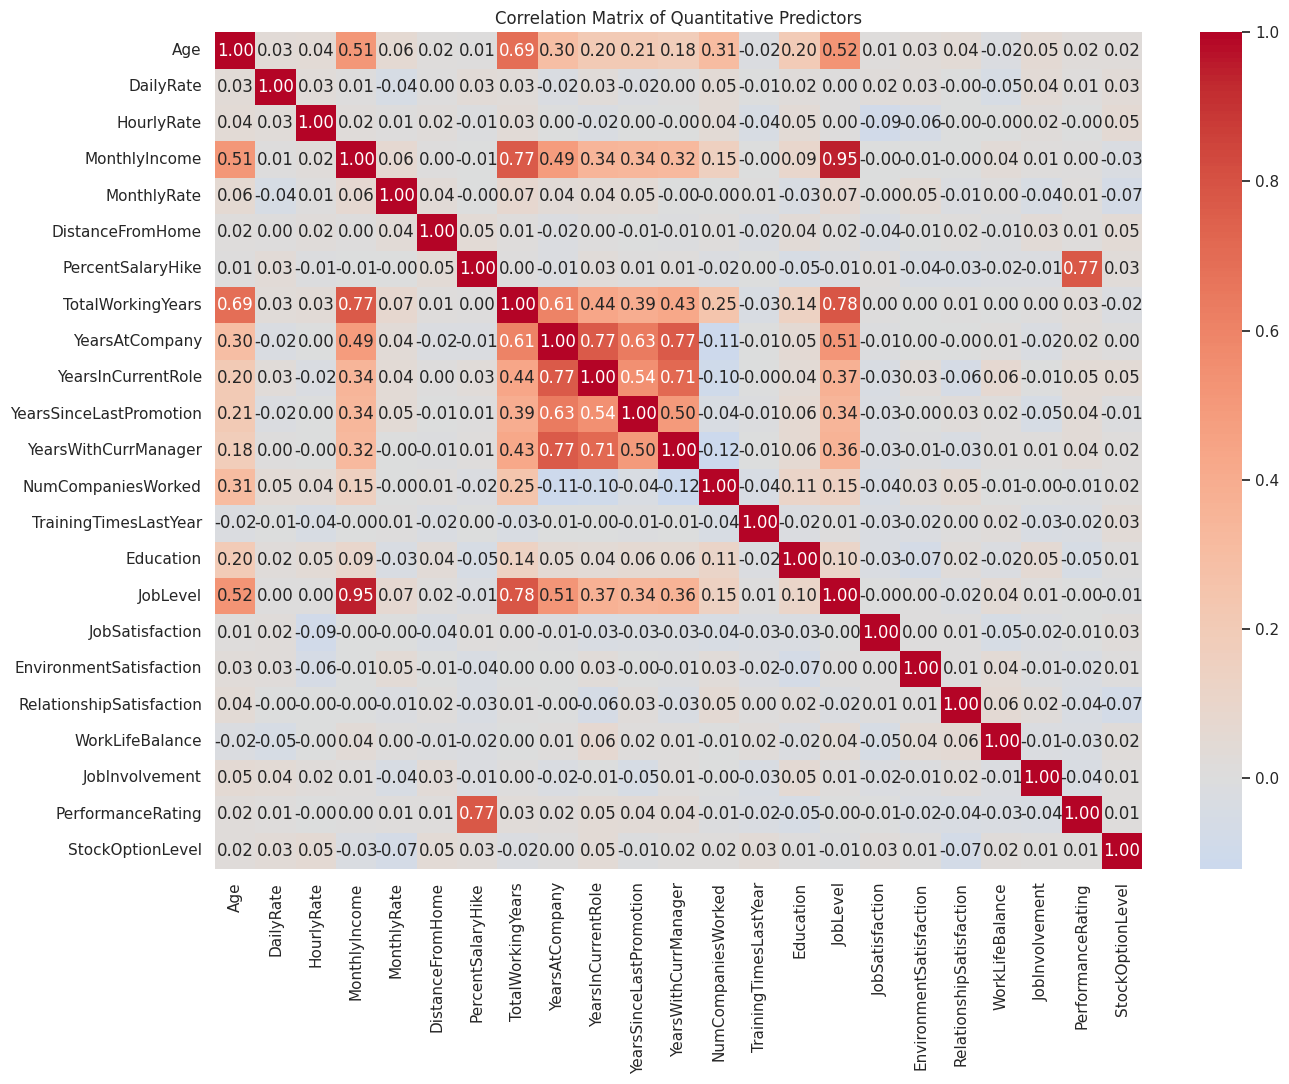

In [24]:
# ============================================================
# 23. CORRELATION MATRIX
# ============================================================

correlation_vars = [
    col for col in vif_continuous + vif_ordinal
    if col in X_train.columns
]

corr_matrix = X_train[correlation_vars].corr()

plt.figure(figsize=(14, 11))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Quantitative Predictors")
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# 24. MANN-WHITNEY U TESTS
# ============================================================

# Variables for the univariate non-parametric analysis
test_numeric_vars = [
    "MonthlyIncome",
    "YearsInCurrentRole",
    "StockOptionLevel",
    "DistanceFromHome",
    "NumCompaniesWorked",
    "TrainingTimesLastYear",
    "PercentSalaryHike",
    "RelationshipSatisfaction"
]

test_numeric_vars = [
    col for col in test_numeric_vars
    if col in X_train.columns
]

train_analysis = X_train.copy()
train_analysis["AttritionBinary"] = y_train.values

group_leave = train_analysis[
    train_analysis["AttritionBinary"] == 1
]

group_stay = train_analysis[
    train_analysis["AttritionBinary"] == 0
]

mann_whitney_results = []

for feature in test_numeric_vars:

    statistic, p_value = mannwhitneyu(
        group_leave[feature],
        group_stay[feature],
        alternative="two-sided"
    )

    mann_whitney_results.append({
        "feature": feature,
        "test": "Mann-Whitney U",
        "U_statistic": statistic,
        "p_value_raw": p_value
    })

mw_results = pd.DataFrame(mann_whitney_results)

display(
    mw_results.sort_values("p_value_raw")
)

,feature,test,U_statistic,p_value_raw
0,MonthlyIncome,Mann-Whitney U,48555.5000,0.0000
1,YearsInCurrentRole,Mann-Whitney U,49856.5000,0.0000
2,StockOptionLevel,Mann-Whitney U,52757.5000,0.0000
3,DistanceFromHome,Mann-Whitney U,80646.0000,0.0099
7,RelationshipSatisfaction,Mann-Whitney U,65250.5000,0.0589
4,NumCompaniesWorked,Mann-Whitney U,77822.5000,0.0702
5,TrainingTimesLastYear,Mann-Whitney U,66974.0000,0.1619
6,PercentSalaryHike,Mann-Whitney U,68518.5000,0.3723


In [26]:
# ============================================================
# 25. EFFECT SIZE FOR MANN-WHITNEY
# ============================================================

def rank_biserial_correlation(U, n1, n2):
    """
    Rank-biserial correlation based on the Mann-Whitney U statistic.
    """
    return (2 * U) / (n1 * n2) - 1


for i, row in mw_results.iterrows():

    feature = row["feature"]

    n_leave = group_leave[feature].notna().sum()
    n_stay = group_stay[feature].notna().sum()

    effect = rank_biserial_correlation(
        row["U_statistic"],
        n_leave,
        n_stay
    )

    mw_results.loc[i, "rank_biserial_r"] = effect


display(
    mw_results.sort_values("p_value_raw")
)

,feature,test,U_statistic,p_value_raw,rank_biserial_r
0,MonthlyIncome,Mann-Whitney U,48555.5000,0.0000,-0.3221
1,YearsInCurrentRole,Mann-Whitney U,49856.5000,0.0000,-0.3040
2,StockOptionLevel,Mann-Whitney U,52757.5000,0.0000,-0.2635
3,DistanceFromHome,Mann-Whitney U,80646.0000,0.0099,0.1259
7,RelationshipSatisfaction,Mann-Whitney U,65250.5000,0.0589,-0.0890
4,NumCompaniesWorked,Mann-Whitney U,77822.5000,0.0702,0.0865
5,TrainingTimesLastYear,Mann-Whitney U,66974.0000,0.1619,-0.0650
6,PercentSalaryHike,Mann-Whitney U,68518.5000,0.3723,-0.0434


In [27]:
# ============================================================
# 26. BENJAMINI-HOCHBERG FDR CORRECTION
# ============================================================

reject, p_adjusted, _, _ = multipletests(
    mw_results["p_value_raw"],
    alpha=ALPHA,
    method="fdr_bh"
)

mw_results["p_value_FDR"] = p_adjusted
mw_results["significant_FDR"] = reject

mw_results = mw_results.sort_values(
    "p_value_FDR"
).reset_index(drop=True)

display(mw_results)

,feature,test,U_statistic,p_value_raw,rank_biserial_r,p_value_FDR,significant_FDR
0,MonthlyIncome,Mann-Whitney U,48555.5000,0.0000,-0.3221,0.0000,True
1,YearsInCurrentRole,Mann-Whitney U,49856.5000,0.0000,-0.3040,0.0000,True
2,StockOptionLevel,Mann-Whitney U,52757.5000,0.0000,-0.2635,0.0000,True
3,DistanceFromHome,Mann-Whitney U,80646.0000,0.0099,0.1259,0.0197,True
4,NumCompaniesWorked,Mann-Whitney U,77822.5000,0.0702,0.0865,0.0936,False
5,RelationshipSatisfaction,Mann-Whitney U,65250.5000,0.0589,-0.0890,0.0936,False
6,TrainingTimesLastYear,Mann-Whitney U,66974.0000,0.1619,-0.0650,0.1850,False
7,PercentSalaryHike,Mann-Whitney U,68518.5000,0.3723,-0.0434,0.3723,False


In [28]:
# ============================================================
# 27. CHI-SQUARE TESTS FOR CATEGORICAL VARIABLES
# ============================================================

chi_square_results = []

for feature in categorical_vars:

    if feature not in X_train.columns:
        continue

    contingency_table = pd.crosstab(
        X_train[feature],
        y_train
    )

    chi2_stat, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    # Check Chi-square expected-frequency assumptions
    min_expected = expected.min()
    num_expected_below_5 = (expected < 5).sum()
    total_expected_cells = expected.size
    percent_expected_below_5 = (
        num_expected_below_5 / total_expected_cells
    ) * 100

    chi_square_results.append({
        "feature": feature,
        "test": "Chi-square",
        "chi2": chi2_stat,
        "df": dof,
        "p_value_raw": p_value,
        "min_expected": min_expected,
        "expected_cells_below_5": num_expected_below_5,
        "percent_expected_below_5": percent_expected_below_5
    })

chi_results = pd.DataFrame(
    chi_square_results
).sort_values(
    "p_value_raw"
).reset_index(drop=True)

display(chi_results)

,feature,test,chi2,df,p_value_raw,min_expected,expected_cells_below_5,percent_expected_below_5
0,JobRole,Chi-square,75.1726,8,0.0000,5.9689,0,0.0000
1,OverTime,Chi-square,46.8629,1,0.0000,48.7191,0,0.0000
2,MaritalStatus,Chi-square,33.6366,2,0.0000,36.7813,0,0.0000
3,BusinessTravel,Chi-square,14.9772,2,0.0006,18.0680,0,0.0000
4,Department,Chi-square,11.1314,2,0.0038,7.0982,0,0.0000
5,EducationField,Chi-square,12.9945,5,0.0234,2.9038,1,8.3333
6,Gender,Chi-square,1.1050,1,0.2932,67.5938,0,0.0000


In [29]:
# ============================================================
# 28. CRAMER'S V EFFECT SIZE
# ============================================================

def cramers_v(contingency_table):

    chi2_stat, _, _, _ = chi2_contingency(
        contingency_table
    )

    n = contingency_table.to_numpy().sum()

    r, k = contingency_table.shape

    phi2 = chi2_stat / n

    phi2_corrected = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    r_corrected = r - (
        ((r - 1) ** 2) / (n - 1)
    )

    k_corrected = k - (
        ((k - 1) ** 2) / (n - 1)
    )

    denominator = min(
        k_corrected - 1,
        r_corrected - 1
    )

    if denominator <= 0:
        return np.nan

    return np.sqrt(
        phi2_corrected / denominator
    )


for i, row in chi_results.iterrows():

    feature = row["feature"]

    contingency_table = pd.crosstab(
        X_train[feature],
        y_train
    )

    chi_results.loc[i, "cramers_v"] = cramers_v(
        contingency_table
    )


display(chi_results)

,feature,test,chi2,df,p_value_raw,min_expected,expected_cells_below_5,percent_expected_below_5,cramers_v
0,JobRole,Chi-square,75.1726,8,0.0000,5.9689,0,0.0000,0.2556
1,OverTime,Chi-square,46.8629,1,0.0000,48.7191,0,0.0000,0.2112
2,MaritalStatus,Chi-square,33.6366,2,0.0000,36.7813,0,0.0000,0.1754
3,BusinessTravel,Chi-square,14.9772,2,0.0006,18.0680,0,0.0000,0.1123
4,Department,Chi-square,11.1314,2,0.0038,7.0982,0,0.0000,0.0942
5,EducationField,Chi-square,12.9945,5,0.0234,2.9038,1,8.3333,0.0882
6,Gender,Chi-square,1.1050,1,0.2932,67.5938,0,0.0000,0.0101


In [30]:
# ============================================================
# 29. FDR CORRECTION FOR CHI-SQUARE TESTS
# ============================================================

reject, p_adjusted, _, _ = multipletests(
    chi_results["p_value_raw"],
    alpha=ALPHA,
    method="fdr_bh"
)

chi_results["p_value_FDR"] = p_adjusted
chi_results["significant_FDR"] = reject

display(chi_results)

,feature,test,chi2,df,p_value_raw,min_expected,expected_cells_below_5,percent_expected_below_5,cramers_v,p_value_FDR,significant_FDR
0,JobRole,Chi-square,75.1726,8,0.0000,5.9689,0,0.0000,0.2556,0.0000,True
1,OverTime,Chi-square,46.8629,1,0.0000,48.7191,0,0.0000,0.2112,0.0000,True
2,MaritalStatus,Chi-square,33.6366,2,0.0000,36.7813,0,0.0000,0.1754,0.0000,True
3,BusinessTravel,Chi-square,14.9772,2,0.0006,18.0680,0,0.0000,0.1123,0.0010,True
4,Department,Chi-square,11.1314,2,0.0038,7.0982,0,0.0000,0.0942,0.0054,True
5,EducationField,Chi-square,12.9945,5,0.0234,2.9038,1,8.3333,0.0882,0.0273,True
6,Gender,Chi-square,1.1050,1,0.2932,67.5938,0,0.0000,0.0101,0.2932,False


In [31]:
# ============================================================
# 30. COMBINED UNIVARIATE RESULTS
# ============================================================

numeric_summary = mw_results[
    [
        "feature",
        "test",
        "p_value_raw",
        "p_value_FDR",
        "significant_FDR",
        "rank_biserial_r"
    ]
].copy()

categorical_summary = chi_results[
    [
        "feature",
        "test",
        "p_value_raw",
        "p_value_FDR",
        "significant_FDR",
        "cramers_v"
    ]
].copy()

univariate_results = pd.concat(
    [
        numeric_summary,
        categorical_summary
    ],
    ignore_index=True
)

display(
    univariate_results.sort_values(
        "p_value_FDR"
    )
)

,feature,test,p_value_raw,p_value_FDR,significant_FDR,rank_biserial_r,cramers_v
8,JobRole,Chi-square,0.0000,0.0000,True,NaN,0.2556
9,OverTime,Chi-square,0.0000,0.0000,True,NaN,0.2112
0,MonthlyIncome,Mann-Whitney U,0.0000,0.0000,True,-0.3221,NaN
1,YearsInCurrentRole,Mann-Whitney U,0.0000,0.0000,True,-0.3040,NaN
2,StockOptionLevel,Mann-Whitney U,0.0000,0.0000,True,-0.2635,NaN
10,MaritalStatus,Chi-square,0.0000,0.0000,True,NaN,0.1754
11,BusinessTravel,Chi-square,0.0006,0.0010,True,NaN,0.1123
12,Department,Chi-square,0.0038,0.0054,True,NaN,0.0942
3,DistanceFromHome,Mann-Whitney U,0.0099,0.0197,True,0.1259,NaN
13,EducationField,Chi-square,0.0234,0.0273,True,NaN,0.0882


In [32]:
# ============================================================
# 31. PRE-SPECIFIED PREDICTORS FOR MULTIVARIABLE MODEL
# ============================================================

# IMPORTANT:
# The univariate Mann-Whitney and Chi-square tests, together with
# FDR correction, are used to answer the first two research hypotheses.
#
# Predictor selection for the multivariable logistic regression
# is NOT based solely on univariate statistical significance.
# Instead, predictors are pre-specified based on the research question,
# previous literature, practical relevance, and avoidance of severe
# multicollinearity.

prespecified_continuous = [
    "MonthlyIncome",
    "YearsInCurrentRole",
    "DistanceFromHome",
    "PercentSalaryHike",
    "NumCompaniesWorked",
    "TrainingTimesLastYear"
]

prespecified_ordinal = [
    "StockOptionLevel"
]

prespecified_categorical = [
    "JobRole",
    "EducationField",
    "BusinessTravel",
    "MaritalStatus",
    "OverTime"
]

candidate_predictors = (
    prespecified_continuous +
    prespecified_ordinal +
    prespecified_categorical
)

# Verify that all selected predictors exist in the training set
missing_predictors = [
    feature
    for feature in candidate_predictors
    if feature not in X_train.columns
]

if missing_predictors:
    raise ValueError(
        f"Missing predictors: {missing_predictors}"
    )

print("Pre-specified predictors for multivariable logistic regression:")
print("--------------------------------------------------------------")

for feature in candidate_predictors:
    print("-", feature)

print(
    "\nPredictor selection is based on research relevance "
    "and multivariable modeling considerations, "
    "not solely on univariate FDR significance."
)

Pre-specified predictors for multivariable logistic regression:
--------------------------------------------------------------
- MonthlyIncome
- YearsInCurrentRole
- DistanceFromHome
- PercentSalaryHike
- NumCompaniesWorked
- TrainingTimesLastYear
- StockOptionLevel
- JobRole
- EducationField
- BusinessTravel
- MaritalStatus
- OverTime

Predictor selection is based on research relevance and multivariable modeling considerations, not solely on univariate FDR significance.


In [33]:
# ============================================================
# 32. MODELING DATAFRAMES
# ============================================================

model_train = X_train[candidate_predictors].copy()
model_train["AttritionBinary"] = y_train.values

model_val = X_val[candidate_predictors].copy()
model_val["AttritionBinary"] = y_val.values

model_test = X_test[candidate_predictors].copy()
model_test["AttritionBinary"] = y_test.values

print("Training model dataframe:")
display(model_train.head())

print("\nTraining model shape:", model_train.shape)
print("Validation model shape:", model_val.shape)
print("Test model shape:", model_test.shape)

Training model dataframe:


,MonthlyIncome,YearsInCurrentRole,DistanceFromHome,PercentSalaryHike,NumCompaniesWorked,TrainingTimesLastYear,StockOptionLevel,JobRole,EducationField,BusinessTravel,MaritalStatus,OverTime,AttritionBinary
853,2552,1,9,25,1,4,0,Research Scientist,Life Sciences,Travel_Rarely,Single,No,0
435,13610,6,15,12,7,2,0,Manager,Medical,Travel_Rarely,Married,Yes,1
587,3149,2,11,20,8,3,1,Laboratory Technician,Life Sciences,Travel_Rarely,Married,No,0
1170,2580,2,2,13,2,0,0,Research Scientist,Medical,Travel_Frequently,Single,No,0
159,2231,3,2,18,6,3,1,Sales Representative,Marketing,Travel_Frequently,Married,No,0



Training model shape: (1029, 13)
Validation model shape: (220, 13)
Test model shape: (221, 13)


In [34]:
# ============================================================
# 33. SCALE MONTHLY INCOME FOR INTERPRETABILITY
# ============================================================

for data in [model_train, model_val, model_test]:

    data["MonthlyIncome_k"] = (
        data["MonthlyIncome"] / 1000
    )

print(
    model_train[
        ["MonthlyIncome", "MonthlyIncome_k"]
    ].head()
)

      MonthlyIncome  MonthlyIncome_k
853            2552           2.5520
435           13610          13.6100
587            3149           3.1490
1170           2580           2.5800
159            2231           2.2310


In [35]:
# ============================================================
# 34. INITIAL MULTIVARIABLE LOGISTIC REGRESSION MODEL
# ============================================================

formula_initial = """
AttritionBinary ~
C(JobRole)
+ C(EducationField)
+ C(StockOptionLevel)
+ MonthlyIncome_k
+ YearsInCurrentRole
+ DistanceFromHome
+ PercentSalaryHike
+ NumCompaniesWorked
+ TrainingTimesLastYear
+ C(OverTime)
+ C(BusinessTravel)
+ C(MaritalStatus)
"""

model_initial = smf.logit(
    formula=formula_initial,
    data=model_train
).fit(
    disp=False
)

print(model_initial.summary())

                           Logit Regression Results                           
Dep. Variable:        AttritionBinary   No. Observations:                 1029
Model:                          Logit   Df Residuals:                     1001
Method:                           MLE   Df Model:                           27
Date:                Sun, 09 Aug 2026   Pseudo R-squ.:                  0.2664
Time:                        14:41:13   Log-Likelihood:                -333.53
converged:                       True   LL-Null:                       -454.67
Covariance Type:            nonrobust   LLR p-value:                 1.753e-36
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 -2.4465      1.253     -1.953      0.051      -4.902       0.009
C(JobRole)[T.Human Resources]              1.24

In [36]:
# ============================================================
# 35. ODDS RATIOS AND 95% CONFIDENCE INTERVALS
# ============================================================

def logistic_results_table(model):

    results = pd.DataFrame({
        "Coefficient": model.params,
        "Odds_Ratio": np.exp(model.params),
        "p_value": model.pvalues,
        "CI_lower_95": np.exp(model.conf_int()[0]),
        "CI_upper_95": np.exp(model.conf_int()[1])
    })

    return results


initial_results = logistic_results_table(
    model_initial
)

display(
    initial_results.round(4)
)

,Coefficient,Odds_Ratio,p_value,CI_lower_95,CI_upper_95
Intercept,-2.4465,0.0866,0.0509,0.0074,1.0092
C(JobRole)[T.Human Resources],1.2417,3.4616,0.1191,0.7263,16.4979
C(JobRole)[T.Laboratory Technician],2.0085,7.4524,0.0005,2.3934,23.2047
C(JobRole)[T.Manager],0.6473,1.9104,0.4655,0.3358,10.8686
C(JobRole)[T.Manufacturing Director],0.1228,1.1307,0.8541,0.3055,4.1844
C(JobRole)[T.Research Director],-1.2898,0.2753,0.3035,0.0236,3.2131
C(JobRole)[T.Research Scientist],0.6305,1.8785,0.2885,0.5865,6.0174
C(JobRole)[T.Sales Executive],1.5131,4.5410,0.0056,1.5559,13.2534
C(JobRole)[T.Sales Representative],2.5141,12.3556,0.0002,3.3371,45.7474
C(EducationField)[T.Life Sciences],-0.7100,0.4916,0.3851,0.0990,2.4410


In [37]:
# ============================================================
# 36. VIF FOR THE ACTUAL MODEL
# ============================================================

from patsy import dmatrices

y_design, X_design = dmatrices(
    formula_initial,
    data=model_train,
    return_type="dataframe"
)

model_vif = calculate_vif(
    X_design.drop(columns=["Intercept"])
)

display(model_vif)

,Variable,VIF
0,C(EducationField)[T.Life Sciences],20.5325
1,C(EducationField)[T.Medical],18.4067
2,C(EducationField)[T.Marketing],9.6296
3,C(EducationField)[T.Technical Degree],8.4952
4,MonthlyIncome_k,5.5567
5,C(EducationField)[T.Other],4.6481
6,C(MaritalStatus)[T.Single],4.2330
7,C(JobRole)[T.Research Scientist],3.1599
8,C(JobRole)[T.Manager],3.1427
9,C(JobRole)[T.Sales Executive],3.0878


In [38]:
# ============================================================
# 37. GENERALIZED LIKELIHOOD RATIO TEST
# ============================================================

from scipy.stats import chi2


def run_glrt(
    reduced_model,
    full_model,
    test_name="GLRT"
):

    # Full model must contain reduced model
    lr_stat = 2 * (
        full_model.llf -
        reduced_model.llf
    )

    df_diff = (
        full_model.df_model -
        reduced_model.df_model
    )

    df_diff = int(round(df_diff))

    p_value = chi2.sf(
        lr_stat,
        df_diff
    )

    result = {
        "test": test_name,
        "LR_statistic": lr_stat,
        "df_difference": df_diff,
        "p_value": p_value
    }

    print("=" * 70)
    print(test_name)
    print("=" * 70)
    print(f"LR statistic: {lr_stat:.4f}")
    print(f"Degrees of freedom: {df_diff}")
    print(f"p-value: {p_value:.6f}")

    if p_value < ALPHA:
        print(
            "Conclusion: the additional terms "
            "significantly improve model fit."
        )
    else:
        print(
            "Conclusion: no significant improvement "
            "from the additional terms."
        )

    return result

In [39]:
# ============================================================
# 38. GLRT: EDUCATION FIELD
# ============================================================

formula_without_education_field = """
AttritionBinary ~
C(JobRole)
+ C(StockOptionLevel)
+ MonthlyIncome_k
+ YearsInCurrentRole
+ DistanceFromHome
+ PercentSalaryHike
+ NumCompaniesWorked
+ TrainingTimesLastYear
+ C(OverTime)
+ C(BusinessTravel)
+ C(MaritalStatus)
"""

model_without_education_field = smf.logit(
    formula=formula_without_education_field,
    data=model_train
).fit(disp=False)

glrt_education = run_glrt(
    model_without_education_field,
    model_initial,
    "EducationField contribution"
)

# Choose the base model according to the EducationField GLRT
if glrt_education["p_value"] < ALPHA:

    base_formula = formula_initial
    base_model = model_initial

    print(
        f"EducationField retained "
        f"(GLRT p = {glrt_education['p_value']:.6f})."
    )

else:

    base_formula = formula_without_education_field
    base_model = model_without_education_field

    print(
        f"EducationField removed "
        f"(GLRT p = {glrt_education['p_value']:.6f})."
    )


# ============================================================
# 39. INTERACTION: OVERTIME × MONTHLY INCOME
# ============================================================

formula_overtime_income = (
    base_formula
    + " + C(OverTime):MonthlyIncome_k"
)

model_overtime_income = smf.logit(
    formula=formula_overtime_income,
    data=model_train
).fit(disp=False)

glrt_overtime_income = run_glrt(
    base_model,
    model_overtime_income,
    "OverTime × MonthlyIncome interaction"
)


# ============================================================
# 40. INTERACTION: DISTANCE × MARITAL STATUS
# ============================================================

formula_distance_marital = (
    base_formula
    + " + DistanceFromHome:C(MaritalStatus)"
)

model_distance_marital = smf.logit(
    formula=formula_distance_marital,
    data=model_train
).fit(disp=False)

glrt_distance_marital = run_glrt(
    base_model,
    model_distance_marital,
    "DistanceFromHome × MaritalStatus interaction"
)


# ============================================================
# 41. SELECT FINAL MODEL SPECIFICATION
# ============================================================

overtime_income_significant = (
    glrt_overtime_income["p_value"] < ALPHA
)

distance_marital_significant = (
    glrt_distance_marital["p_value"] < ALPHA
)

if overtime_income_significant and distance_marital_significant:

    final_formula = (
        base_formula
        + " + C(OverTime):MonthlyIncome_k"
        + " + DistanceFromHome:C(MaritalStatus)"
    )

    print(
        "Selected final specification: "
        "both interactions included."
    )

elif overtime_income_significant:

    final_formula = formula_overtime_income

    print(
        "Selected final specification: "
        "OverTime × MonthlyIncome interaction included."
    )

elif distance_marital_significant:

    final_formula = formula_distance_marital

    print(
        "Selected final specification: "
        "DistanceFromHome × MaritalStatus interaction included."
    )

else:

    final_formula = base_formula

    print(
        "Selected final specification: "
        "no tested interactions included."
    )

# ============================================================
# 42. FIT FINAL MODEL
# ============================================================

model_final = smf.logit(
    formula=final_formula,
    data=model_train
).fit(disp=False)

print("\nFINAL MODEL FORMULA")
print("-------------------")
print(final_formula)

print("\nFINAL MODEL SUMMARY")
print("-------------------")
print(model_final.summary())

EducationField contribution
LR statistic: 6.5350
Degrees of freedom: 5
p-value: 0.257582
Conclusion: no significant improvement from the additional terms.
EducationField removed (GLRT p = 0.257582).
OverTime × MonthlyIncome interaction
LR statistic: 0.0000
Degrees of freedom: 1
p-value: 0.996332
Conclusion: no significant improvement from the additional terms.
DistanceFromHome × MaritalStatus interaction
LR statistic: 0.6843
Degrees of freedom: 2
p-value: 0.710234
Conclusion: no significant improvement from the additional terms.
Selected final specification: no tested interactions included.

FINAL MODEL FORMULA
-------------------

AttritionBinary ~
C(JobRole)
+ C(StockOptionLevel)
+ MonthlyIncome_k
+ YearsInCurrentRole
+ DistanceFromHome
+ PercentSalaryHike
+ NumCompaniesWorked
+ TrainingTimesLastYear
+ C(OverTime)
+ C(BusinessTravel)
+ C(MaritalStatus)


FINAL MODEL SUMMARY
-------------------
                           Logit Regression Results                           
Dep. Variabl

In [40]:
# ============================================================
# 43. FINAL MODEL RESULTS
# ============================================================

final_results = logistic_results_table(
    model_final
)

display(
    final_results.round(4)
)

,Coefficient,Odds_Ratio,p_value,CI_lower_95,CI_upper_95
Intercept,-3.2730,0.0379,0.0006,0.0058,0.2486
C(JobRole)[T.Human Resources],1.6274,5.0908,0.0167,1.3433,19.2926
C(JobRole)[T.Laboratory Technician],2.0066,7.4377,0.0005,2.4027,23.0239
C(JobRole)[T.Manager],0.6827,1.9791,0.4418,0.3476,11.2692
C(JobRole)[T.Manufacturing Director],0.1568,1.1698,0.8145,0.3155,4.3365
C(JobRole)[T.Research Director],-1.3626,0.2560,0.2760,0.0221,2.9717
C(JobRole)[T.Research Scientist],0.6747,1.9634,0.2536,0.6166,6.2516
C(JobRole)[T.Sales Executive],1.6174,5.0401,0.0023,1.7844,14.2357
C(JobRole)[T.Sales Representative],2.6831,14.6307,0.0000,4.0768,52.5057
C(StockOptionLevel)[T.1],-1.5920,0.2035,0.0000,0.1045,0.3965


In [41]:
# ============================================================
# 44. MODEL GOODNESS OF FIT
# ============================================================

null_model = smf.logit(
    "AttritionBinary ~ 1",
    data=model_train
).fit(
    disp=False
)

mcfadden_r2 = 1 - (
    model_final.llf /
    null_model.llf
)

goodness_of_fit = pd.DataFrame({
    "Metric": [
        "Log-Likelihood",
        "AIC",
        "BIC",
        "McFadden Pseudo-R²"
    ],
    "Value": [
        model_final.llf,
        model_final.aic,
        model_final.bic,
        mcfadden_r2
    ]
})

display(
    goodness_of_fit.round(4)
)

,Metric,Value
0,Log-Likelihood,-336.7950
1,AIC,719.5900
2,BIC,833.1259
3,McFadden Pseudo-R²,0.2593


In [42]:
# ============================================================
# 45. TRAINING PREDICTIONS
# ============================================================

train_prob = model_final.predict(
    model_train
)

print("First predicted probabilities:")
display(train_prob.head())

First predicted probabilities:


,0
853,0.0897
435,0.3522
587,0.1572
1170,0.2300
159,0.3040


In [43]:
# ============================================================
# 46. VALIDATION PREDICTIONS
# ============================================================

val_prob = model_final.predict(
    model_val
)

print("Validation ROC-AUC:")
print(
    roc_auc_score(
        model_val["AttritionBinary"],
        val_prob
    )
)

Validation ROC-AUC:
0.7701930501930502


In [44]:
# ============================================================
# 47. THRESHOLD SELECTION USING VALIDATION SET
# ============================================================

fpr, tpr, thresholds = roc_curve(
    model_val["AttritionBinary"],
    val_prob
)

youden_j = tpr - fpr

best_index = np.argmax(
    youden_j
)

selected_threshold = thresholds[
    best_index
]

print(
    f"Selected threshold: "
    f"{selected_threshold:.4f}"
)

Selected threshold: 0.2044


In [45]:
# ============================================================
# 48. VALIDATION PERFORMANCE
# ============================================================

val_pred = (
    val_prob >= selected_threshold
).astype(int)

print(
    classification_report(
        model_val["AttritionBinary"],
        val_pred,
        target_names=[
            "Stayed",
            "Left"
        ]
    )
)

print(
    "Validation ROC-AUC:",
    roc_auc_score(
        model_val["AttritionBinary"],
        val_prob
    )
)

print(
    "Validation PR-AUC:",
    average_precision_score(
        model_val["AttritionBinary"],
        val_prob
    )
)

              precision    recall  f1-score   support

      Stayed       0.93      0.83      0.88       185
        Left       0.43      0.69      0.53        35

    accuracy                           0.80       220
   macro avg       0.68      0.76      0.70       220
weighted avg       0.85      0.80      0.82       220

Validation ROC-AUC: 0.7701930501930502
Validation PR-AUC: 0.5140769110611343


In [46]:
# ============================================================
# 49. FINAL TEST EVALUATION
# ============================================================

test_prob = model_final.predict(
    model_test
)

test_pred = (
    test_prob >= selected_threshold
).astype(int)

y_test_final = model_test[
    "AttritionBinary"
]

print("=" * 70)
print("FINAL TEST SET PERFORMANCE")
print("=" * 70)

print(
    "\nROC-AUC:",
    roc_auc_score(
        y_test_final,
        test_prob
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test_final,
        test_prob
    )
)

print(
    "Accuracy:",
    accuracy_score(
        y_test_final,
        test_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_test_final,
        test_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test_final,
        test_pred,
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        y_test_final,
        test_pred,
        zero_division=0
    )

)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_test_final,
        test_pred
    )
)

print(
    "Brier Score:",
    brier_score_loss(
        y_test_final,
        test_prob
    )
)

FINAL TEST SET PERFORMANCE

ROC-AUC: 0.7971471471471471
PR-AUC: 0.5326125806222706
Accuracy: 0.7420814479638009
Precision: 0.352112676056338
Recall: 0.6944444444444444
F1: 0.4672897196261682
Balanced Accuracy: 0.7228978978978979
Brier Score: 0.10876071718138458


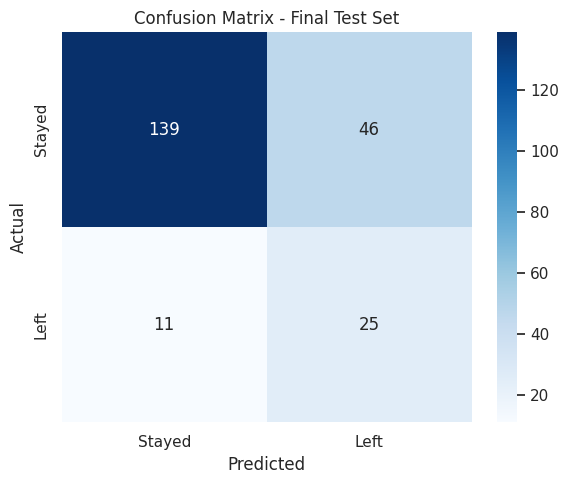

In [47]:
# ============================================================
# 50. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test_final,
    test_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Test Set")

plt.tight_layout()
plt.show()

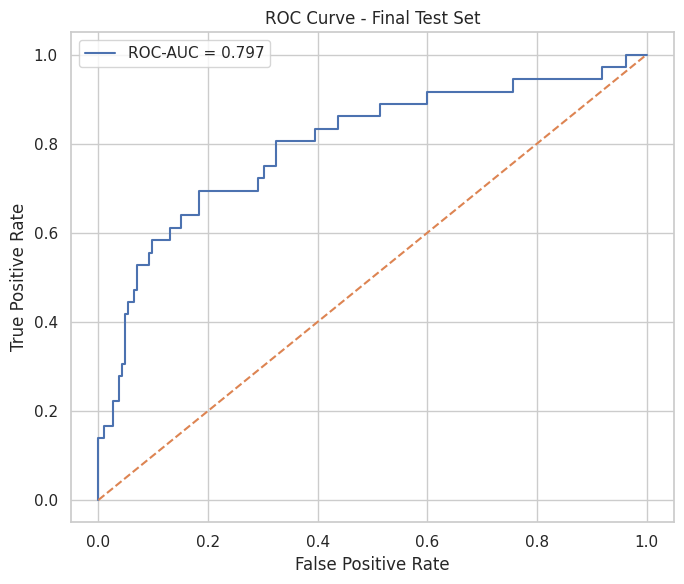

In [48]:
# ============================================================
# 51. ROC CURVE
# ============================================================

test_fpr, test_tpr, _ = roc_curve(
    y_test_final,
    test_prob
)

test_auc = roc_auc_score(
    y_test_final,
    test_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    test_fpr,
    test_tpr,
    label=f"ROC-AUC = {test_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Test Set")
plt.legend()

plt.tight_layout()
plt.show()

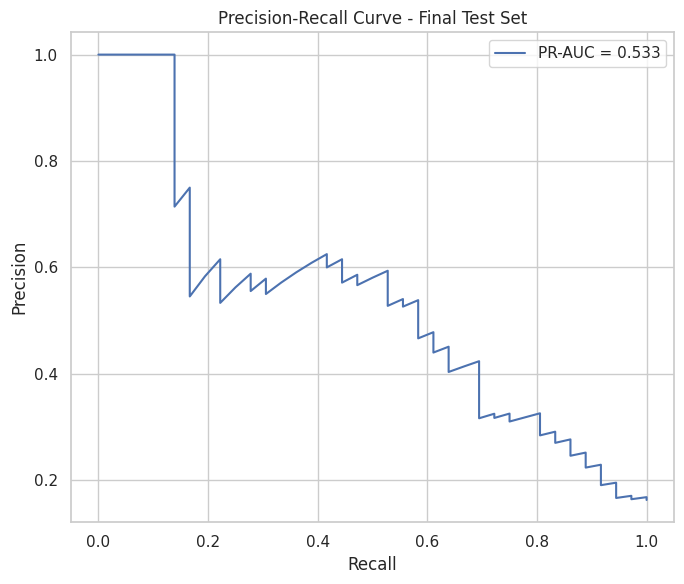

In [49]:
# ============================================================
# 52. PRECISION-RECALL CURVE
# ============================================================

precision, recall, _ = precision_recall_curve(
    y_test_final,
    test_prob
)

pr_auc = average_precision_score(
    y_test_final,
    test_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {pr_auc:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final Test Set")
plt.legend()

plt.tight_layout()
plt.show()

In [50]:
# ============================================================
# 53. FINAL RESULTS TABLE FOR THE PAPER
# ============================================================

paper_results = final_results.copy()

paper_results["Significant_0.05"] = (
    paper_results["p_value"] < ALPHA
)

paper_results = paper_results.sort_values(
    "p_value"
)

display(
    paper_results.round(4)
)

,Coefficient,Odds_Ratio,p_value,CI_lower_95,CI_upper_95,Significant_0.05
C(OverTime)[T.Yes],1.5124,4.5377,0.0000,3.0149,6.8296,True
C(StockOptionLevel)[T.1],-1.5920,0.2035,0.0000,0.1045,0.3965,True
C(JobRole)[T.Sales Representative],2.6831,14.6307,0.0000,4.0768,52.5057,True
C(BusinessTravel)[T.Travel_Frequently],1.6579,5.2483,0.0002,2.1822,12.6225,True
C(JobRole)[T.Laboratory Technician],2.0066,7.4377,0.0005,2.4027,23.0239,True
Intercept,-3.2730,0.0379,0.0006,0.0058,0.2486,True
C(StockOptionLevel)[T.2],-1.6252,0.1969,0.0007,0.0769,0.5041,True
YearsInCurrentRole,-0.1176,0.8890,0.0009,0.8292,0.9532,True
DistanceFromHome,0.0378,1.0385,0.0017,1.0143,1.0633,True
C(JobRole)[T.Sales Executive],1.6174,5.0401,0.0023,1.7844,14.2357,True


In [51]:
# ============================================================
# 54. GLRT SUMMARY TABLE
# ============================================================

glrt_summary = pd.DataFrame([
    glrt_education,
    glrt_overtime_income,
    glrt_distance_marital
])

display(
    glrt_summary.round(4)
)

,test,LR_statistic,df_difference,p_value
0,EducationField contribution,6.5350,5,0.2576
1,OverTime × MonthlyIncome interaction,0.0000,1,0.9963
2,DistanceFromHome × MaritalStatus interaction,0.6843,2,0.7102


In [52]:
# ============================================================
# 55. FINAL MODEL VIF
# ============================================================

y_final_design, X_final_design = dmatrices(
    final_formula,
    data=model_train,
    return_type="dataframe"
)

final_vif = calculate_vif(
    X_final_design.drop(
        columns=["Intercept"]
    )
)

display(final_vif)

,Variable,VIF
0,MonthlyIncome_k,5.5227
1,C(MaritalStatus)[T.Single],4.1963
2,C(JobRole)[T.Research Scientist],3.1535
3,C(JobRole)[T.Manager],3.1192
4,C(JobRole)[T.Laboratory Technician],3.0383
5,C(StockOptionLevel)[T.1],2.9789
6,C(JobRole)[T.Sales Executive],2.7360
7,C(JobRole)[T.Research Director],2.3120
8,C(BusinessTravel)[T.Travel_Frequently],2.2194
9,C(BusinessTravel)[T.Travel_Rarely],2.2067


In [53]:
# ============================================================
# 56. FINAL MODEL DIAGNOSTIC SUMMARY
# ============================================================

diagnostics = {
    "Number of training observations": len(model_train),
    "Number of validation observations": len(model_val),
    "Number of test observations": len(model_test),
    "Number of model parameters": len(model_final.params),
    "Log-Likelihood": model_final.llf,
    "AIC": model_final.aic,
    "BIC": model_final.bic,
    "McFadden Pseudo-R2": mcfadden_r2,
    "Validation ROC-AUC": roc_auc_score(
        model_val["AttritionBinary"],
        val_prob
    ),
    "Validation PR-AUC": average_precision_score(
        model_val["AttritionBinary"],
        val_prob
    ),
    "Selected threshold": selected_threshold,
    "Test ROC-AUC": roc_auc_score(
        y_test_final,
        test_prob
    ),
    "Test PR-AUC": average_precision_score(
        y_test_final,
        test_prob
    ),
    "Test F1": f1_score(
        y_test_final,
        test_pred,
        zero_division=0
    ),
    "Test Balanced Accuracy": balanced_accuracy_score(
        y_test_final,
        test_pred
    )
}

diagnostics_table = pd.Series(
    diagnostics,
    name="Value"
).to_frame()

display(
    diagnostics_table.round(4)
)

,Value
Number of training observations,1029.0000
Number of validation observations,220.0000
Number of test observations,221.0000
Number of model parameters,23.0000
Log-Likelihood,-336.7950
AIC,719.5900
BIC,833.1259
McFadden Pseudo-R2,0.2593
Validation ROC-AUC,0.7702
Validation PR-AUC,0.5141


In [54]:
# ============================================================
# 57. SIGNIFICANT FINAL PREDICTORS
# ============================================================

significant_final = paper_results[
    paper_results["Significant_0.05"]
].copy()

print("Statistically significant terms in the final model:")
display(
    significant_final.round(4)
)

Statistically significant terms in the final model:


,Coefficient,Odds_Ratio,p_value,CI_lower_95,CI_upper_95,Significant_0.05
C(OverTime)[T.Yes],1.5124,4.5377,0.0000,3.0149,6.8296,True
C(StockOptionLevel)[T.1],-1.5920,0.2035,0.0000,0.1045,0.3965,True
C(JobRole)[T.Sales Representative],2.6831,14.6307,0.0000,4.0768,52.5057,True
C(BusinessTravel)[T.Travel_Frequently],1.6579,5.2483,0.0002,2.1822,12.6225,True
C(JobRole)[T.Laboratory Technician],2.0066,7.4377,0.0005,2.4027,23.0239,True
Intercept,-3.2730,0.0379,0.0006,0.0058,0.2486,True
C(StockOptionLevel)[T.2],-1.6252,0.1969,0.0007,0.0769,0.5041,True
YearsInCurrentRole,-0.1176,0.8890,0.0009,0.8292,0.9532,True
DistanceFromHome,0.0378,1.0385,0.0017,1.0143,1.0633,True
C(JobRole)[T.Sales Executive],1.6174,5.0401,0.0023,1.7844,14.2357,True


In [55]:
# ============================================================
# 58. COMPACT FINAL RESULTS
# ============================================================

print("=" * 80)
print("FINAL ANALYSIS SUMMARY")
print("=" * 80)

print(
    f"\nFinal model formula:\n{final_formula}"
)

print(
    f"\nValidation ROC-AUC: "
    f"{roc_auc_score(model_val['AttritionBinary'], val_prob):.3f}"
)

print(
    f"Test ROC-AUC: "
    f"{roc_auc_score(y_test_final, test_prob):.3f}"
)

print(
    f"Test PR-AUC: "
    f"{average_precision_score(y_test_final, test_prob):.3f}"
)

print(
    f"Selected threshold: "
    f"{selected_threshold:.3f}"
)

print("\nSignificant final-model terms:")
for term in significant_final.index:
    print(f"  - {term}")

FINAL ANALYSIS SUMMARY

Final model formula:

AttritionBinary ~
C(JobRole)
+ C(StockOptionLevel)
+ MonthlyIncome_k
+ YearsInCurrentRole
+ DistanceFromHome
+ PercentSalaryHike
+ NumCompaniesWorked
+ TrainingTimesLastYear
+ C(OverTime)
+ C(BusinessTravel)
+ C(MaritalStatus)


Validation ROC-AUC: 0.770
Test ROC-AUC: 0.797
Test PR-AUC: 0.533
Selected threshold: 0.204

Significant final-model terms:
  - C(OverTime)[T.Yes]
  - C(StockOptionLevel)[T.1]
  - C(JobRole)[T.Sales Representative]
  - C(BusinessTravel)[T.Travel_Frequently]
  - C(JobRole)[T.Laboratory Technician]
  - Intercept
  - C(StockOptionLevel)[T.2]
  - YearsInCurrentRole
  - DistanceFromHome
  - C(JobRole)[T.Sales Executive]
  - NumCompaniesWorked
  - C(JobRole)[T.Human Resources]
  - C(BusinessTravel)[T.Travel_Rarely]


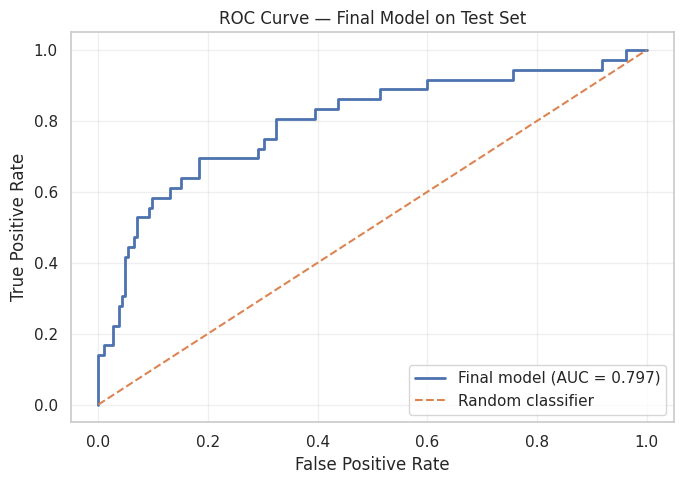

Test ROC-AUC: 0.797


In [56]:
# ============================================================
# ROC CURVE — FINAL MODEL ON TEST SET
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, test_prob)

# Calculate ROC-AUC
test_roc_auc = roc_auc_score(y_test, test_prob)

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Final model (AUC = {test_roc_auc:.3f})"
)

# Random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Model on Test Set")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()

# Save for the paper
plt.savefig(
    "test_roc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Test ROC-AUC: {test_roc_auc:.3f}")
